In [346]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [347]:
nr_of_seeds = 10 #nr of seeds in the experiments
index = 925

In [348]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [349]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12268\3749485441.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_12268\3749485441.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

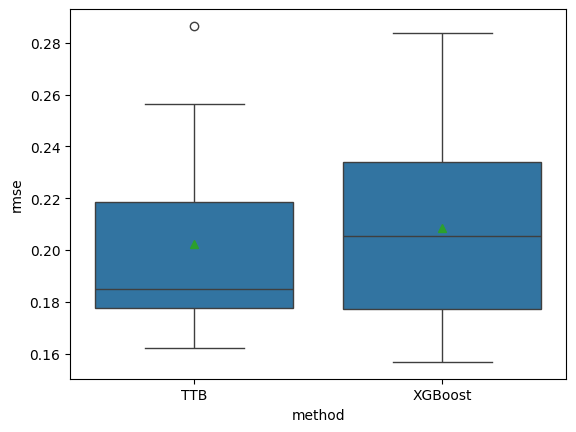

In [350]:


dat = pd.read_csv(f'results/ttb_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [351]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
41,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,850.0,400.0,0.154042,0.116975,0.256569,0.185703,TransferTreeBoost
337,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,854.0,400.0,0.198177,0.155384,0.286537,0.175205,TransferTreeBoost
422,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,855.0,400.0,0.196616,0.166717,0.178290,0.141335,TransferTreeBoost
105,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,851.0,400.0,0.172936,0.139285,0.209776,0.164059,TransferTreeBoost
481,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,856.0,400.0,0.178102,0.143515,0.221273,0.146250,TransferTreeBoost
630,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,858.0,400.0,0.310605,0.195722,0.177352,0.149116,TransferTreeBoost
281,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,853.0,400.0,0.260172,0.198683,0.162222,0.124105,TransferTreeBoost
569,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,857.0,400.0,0.171302,0.137198,0.163051,0.126842,TransferTreeBoost
158,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,852.0,400.0,0.202243,0.152771,0.178570,0.144692,TransferTreeBoost
689,0.1,1.0,1.0,0.0,0.5,0.20247,0.149219,10,859.0,400.0,0.247098,0.196659,0.191062,0.134882,TransferTreeBoost
